
# EDA: Zhao (2020) Flow-Boiling CHF in Tubes (`zhao2020_chf_flowboiling_tubes.csv`)

Literature-compiled flow-boiling CHF dataset for tubes, spanning many source
studies (`author`) and both circular and non-circular (`geometry`) test
sections.

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/zhao2020_chf_flowboiling_tubes")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SLUG = "zhao2020_chf_flowboiling_tubes"
SLUG_TITLE = "Zhao (2020) Flow-Boiling CHF (Tubes)"

df = pd.read_csv(DATA_DIR / "zhao2020_chf_flowboiling_tubes.csv", encoding="utf-8-sig")

NUMERIC_COLS = ["pressure [MPa]", "mass_flux [kg/m2-s]", "x_e_out [-]", "D_e [mm]",
                 "D_h [mm]", "length [mm]", "chf_exp [MW/m2]"]
CATEGORICAL_COLS = ["author", "geometry"]
TARGET_COL = "chf_exp [MW/m2]"

df.head()

,id,author,geometry,pressure [MPa],mass_flux [kg/m2-s],x_e_out [-],D_e [mm],D_h [mm],length [mm],chf_exp [MW/m2]
0,1,Inasaka,tube,0.39,5600,-0.1041,3.0,3.0,100,11.3
1,2,Inasaka,tube,0.31,6700,-0.0596,3.0,3.0,100,10.6
2,3,Inasaka,tube,0.33,4300,-0.0395,3.0,3.0,100,7.3
3,4,Inasaka,tube,0.62,6400,-0.1460,3.0,3.0,100,12.8
4,5,Inasaka,tube,0.64,4700,-0.0849,3.0,3.0,100,11.0


## 2. Data Quality

In [2]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing if len(missing) else "None")
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (1865, 10)

Dtypes:
id                       int64
author                  object
geometry                object
pressure [MPa]         float64
mass_flux [kg/m2-s]      int64
x_e_out [-]            float64
D_e [mm]               float64
D_h [mm]               float64
length [mm]              int64
chf_exp [MW/m2]        float64
dtype: object

Missing values per column:
None

Duplicate rows: 0


## 3. Descriptive Statistics

In [3]:
numeric_summary = df[NUMERIC_COLS].describe().T
numeric_summary.to_csv(OUT_DIR / "summary_stats.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max
pressure [MPa],1865.0,10.010949,4.282715,0.1000,6.8900,10.3400,13.7900,20.680
mass_flux [kg/m2-s],1865.0,2862.647721,1656.412247,0.0000,1519.0000,2590.0000,3933.0000,7975.000
x_e_out [-],1865.0,0.016179,0.117575,-0.8667,-0.0483,0.0244,0.1006,0.232
D_e [mm],1865.0,9.417212,6.333807,1.0000,5.6000,8.5000,11.1000,37.500
D_h [mm],1865.0,16.167721,21.182870,1.0000,5.6000,10.3000,15.2000,120.000
length [mm],1865.0,911.340483,726.718974,10.0000,432.0000,625.0000,1778.0000,3048.000
chf_exp [MW/m2],1865.0,3.854638,1.985535,0.8000,2.4000,3.5000,4.8000,19.300


## 4. Categorical Value Counts

In [4]:
for col in CATEGORICAL_COLS:
    print(f"--- {col} (n_unique={df[col].nunique(dropna=True)}) ---")
    print(df[col].value_counts(dropna=False).head(15))
    print()

--- author (n_unique=10) ---
author
Thompson        1202
Janssen          282
Weatherhead      162
Beus              77
Williams          51
Richenderfer      36
Mortimore         19
Peskov            17
Kossolapov        12
Inasaka            7
Name: count, dtype: int64

--- geometry (n_unique=3) ---
geometry
tube       1439
annulus     378
plate        48
Name: count, dtype: int64



## 5. Univariate Distributions

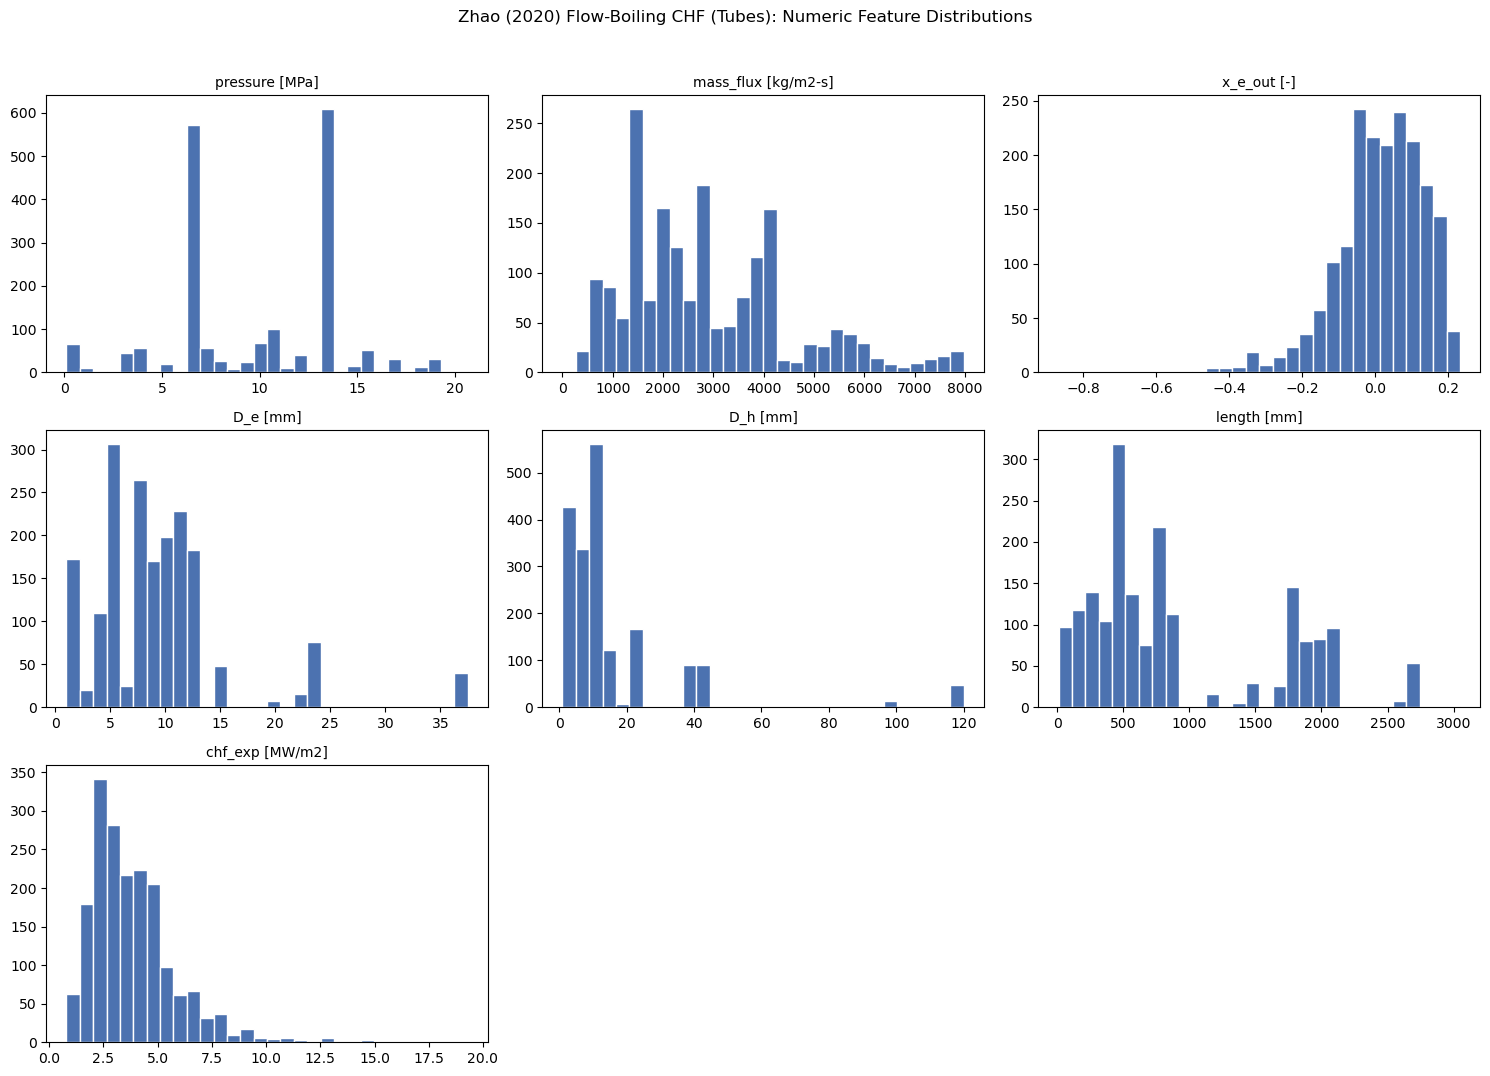

In [5]:
n = len(NUMERIC_COLS)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=10)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: Numeric Feature Distributions", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Outlier Scan (IQR, z-score)

In [6]:
iqr_rows = []
for col in NUMERIC_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    iqr_rows.append({
        "column": col, "q1": q1, "q3": q3, "iqr": iqr,
        "lower_fence": lo, "upper_fence": hi,
        "n_outliers": n_out, "pct_outliers": 100 * n_out / len(s) if len(s) else np.nan,
    })
iqr_table = pd.DataFrame(iqr_rows).set_index("column")
iqr_table.to_csv(OUT_DIR / "iqr_outlier_summary.csv")
iqr_table

,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
column,,,,,,,
pressure [MPa],6.8900,13.7900,6.9000,-3.46000,24.14000,0,0.000000
mass_flux [kg/m2-s],1519.0000,3933.0000,2414.0000,-2102.00000,7554.00000,25,1.340483
x_e_out [-],-0.0483,0.1006,0.1489,-0.27165,0.32395,43,2.305630
D_e [mm],5.6000,11.1000,5.5000,-2.65000,19.35000,139,7.453083
D_h [mm],5.6000,15.2000,9.6000,-8.80000,29.60000,244,13.083110
length [mm],432.0000,1778.0000,1346.0000,-1587.00000,3797.00000,0,0.000000
chf_exp [MW/m2],2.4000,4.8000,2.4000,-1.20000,8.40000,56,3.002681


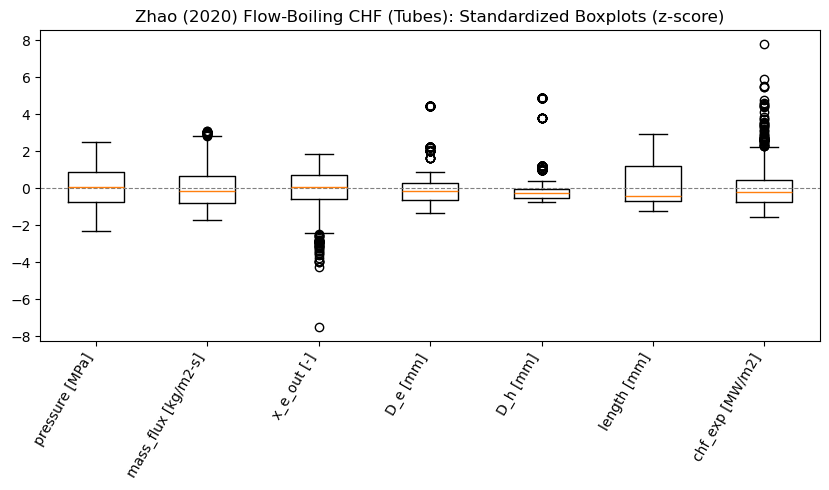

In [7]:
z = df[NUMERIC_COLS].apply(lambda s: (s - s.mean()) / s.std())
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(NUMERIC_COLS)), 5))
ax.boxplot([z[c].dropna() for c in NUMERIC_COLS])
ax.set_xticklabels(NUMERIC_COLS, rotation=60, ha="right")
ax.set_title(f"{SLUG_TITLE}: Standardized Boxplots (z-score)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
fig.tight_layout()
fig.savefig(FIG_DIR / "boxplots_standardized.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlation Structure

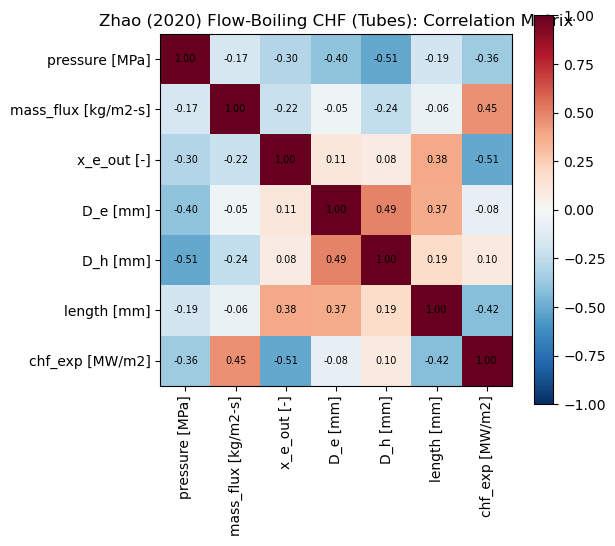

In [8]:
corr = df[NUMERIC_COLS].corr()
corr.to_csv(OUT_DIR / "correlation_matrix.csv")
fig, ax = plt.subplots(figsize=(0.6 * len(NUMERIC_COLS) + 2, 0.6 * len(NUMERIC_COLS) + 2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels(NUMERIC_COLS, rotation=90)
ax.set_yticks(range(len(NUMERIC_COLS)))
ax.set_yticklabels(NUMERIC_COLS)
for i in range(len(NUMERIC_COLS)):
    for j in range(len(NUMERIC_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title(f"{SLUG_TITLE}: Correlation Matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Target vs. Features

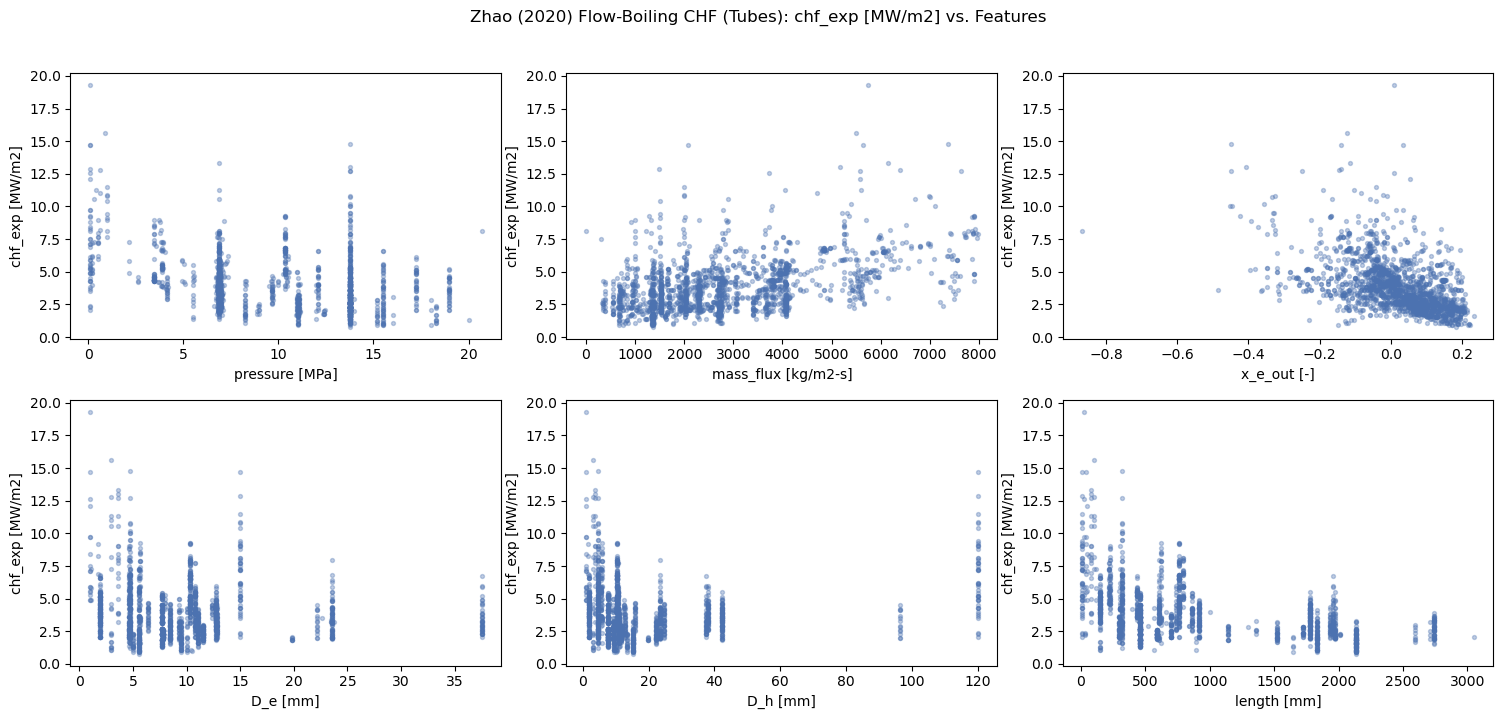

In [9]:
feature_cols = [c for c in NUMERIC_COLS if c != TARGET_COL]
n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df[TARGET_COL], s=8, alpha=0.35, color="#4C72B0")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: {TARGET_COL} vs. Features", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "target_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Target by Category

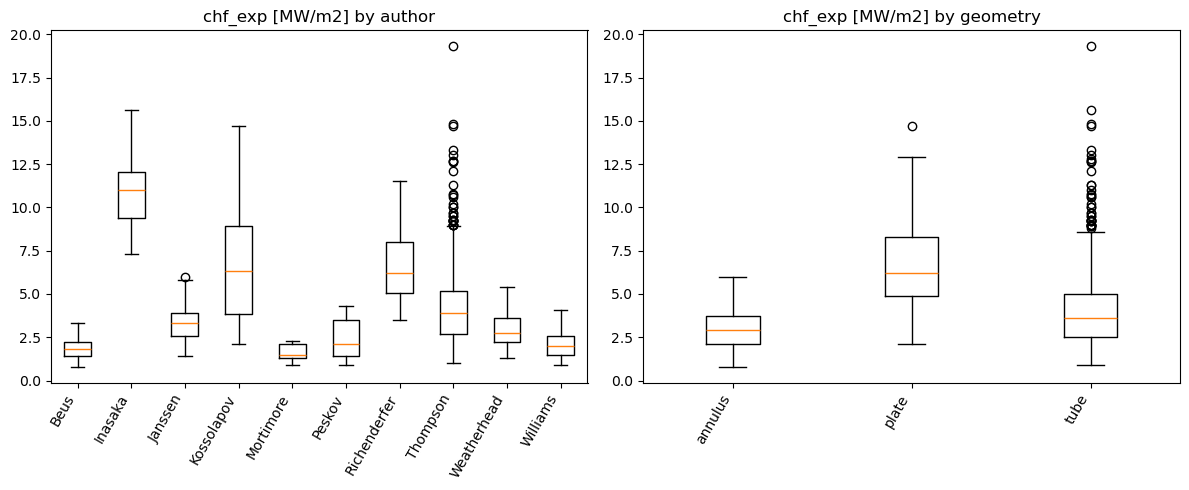

In [10]:
cat_cols_plot = [c for c in CATEGORICAL_COLS
                 if 2 <= df[c].nunique(dropna=True) <= 15]
if cat_cols_plot:
    fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(6 * len(cat_cols_plot), 5), squeeze=False)
    axes = axes[0]
    for ax, col in zip(axes, cat_cols_plot):
        groups = [g[TARGET_COL].dropna().values for _, g in df.groupby(col)]
        labels = [str(k) for k, _ in df.groupby(col)]
        ax.boxplot(groups)
        ax.set_xticklabels(labels, rotation=60, ha="right")
        ax.set_title(f"{TARGET_COL} by {col}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "target_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No low-cardinality categorical columns (2-15 unique values) available for grouped comparison.")

## 10. Coverage by Author (Source Study)

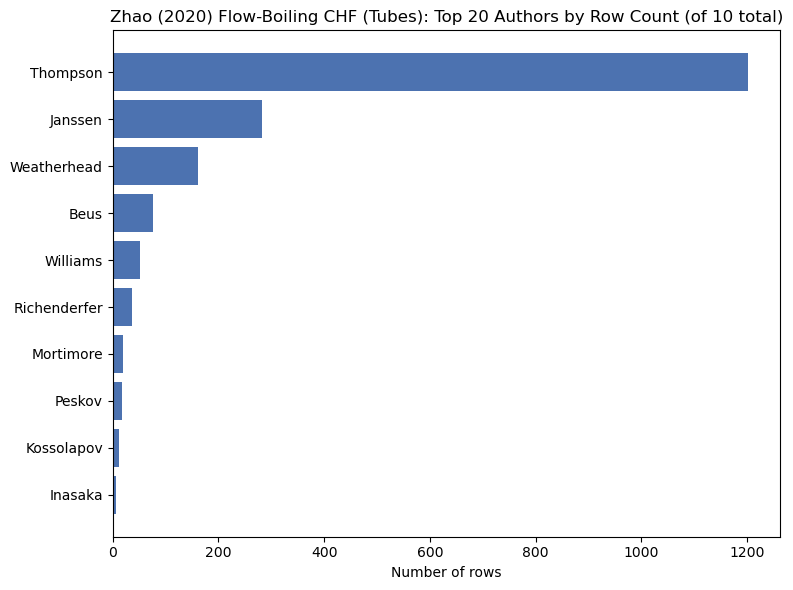

In [11]:
top_authors = df["author"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_authors.index.astype(str)[::-1], top_authors.values[::-1], color="#4C72B0")
ax.set_xlabel("Number of rows")
ax.set_title(f"{SLUG_TITLE}: Top 20 Authors by Row Count "
             f"(of {df['author'].nunique()} total)")
fig.tight_layout()
fig.savefig(FIG_DIR / "top_authors.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Takeaways

- `chf_exp [MW/m2]` is the target; `D_e`/`D_h` (equivalent/hydraulic
  diameter) are near-duplicate columns for circular tubes and will show
  strong collinearity in the correlation matrix — check whether `geometry`
  explains any divergence between them.
- `author` is high-cardinality (many literature sources at uneven sample
  counts); consider grouping rare authors into an "other" bucket for any
  categorical-encoding use, or use it only for source-aware validation
  splits.
- `x_e_out [-]` (exit quality) can be negative (subcooled exit) — confirm the
  histogram range matches physical expectations for flow boiling.
